In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [3]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

<Axes: xlabel='edad', ylabel='altura'>

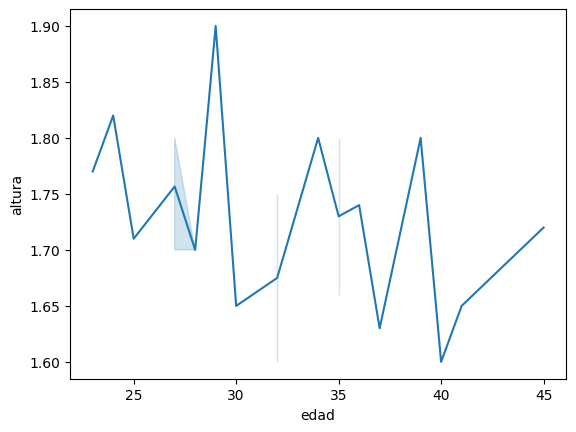

In [5]:
# pasamos a pandas para trabajar y
df_alumnos = pd.DataFrame (lista_alumnos, columns=("nombre", 'edad', 'altura'))
sns.lineplot (data = df_alumnos, x='edad', y='altura')


### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

No, porque no hay una relación lineal entre las dos variables

### Entrena un modelo de regresión lineal

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [6]:
#Por convención la X es mayúscula y la y minúscula
y = df_alumnos ['altura'] # lo que quiero predecir
# la variable de entrada. Tiene que ser un dataframe, por eso dobles corchetes. Si no, da error
X = df_alumnos [['edad']] 
#creamos los 4 grupos para train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
# creamos el  objeto
lm = LinearRegression() 
#lo entrenamos
lm.fit (X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

<Axes: xlabel='altura'>

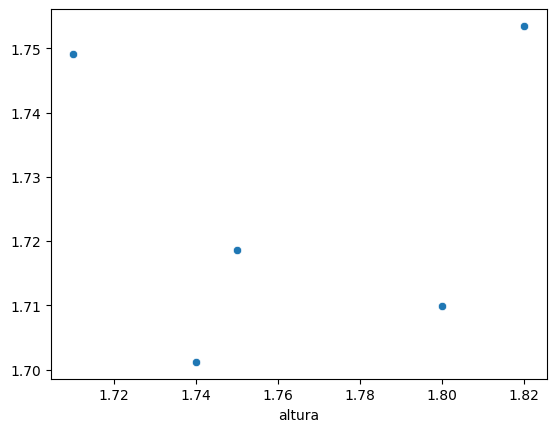

In [8]:
predictions = lm.predict (X_test)
#comparamos con lo real
sns.scatterplot (x=y_test, y=predictions)

In [9]:
df_eval = pd.DataFrame(X_test)
df_eval['Prediccion'] = predictions
df_eval["Valor_real"] = y_test
df_eval['error'] = abs(df_eval['Prediccion'] - df_eval["Valor_real"])
df_eval

,edad,Prediccion,Valor_real,error
0,24,1.753478,1.82,0.066522
17,34,1.709906,1.80,0.090094
15,32,1.718621,1.75,0.031379
1,25,1.749121,1.71,0.039121
8,36,1.701192,1.74,0.038808


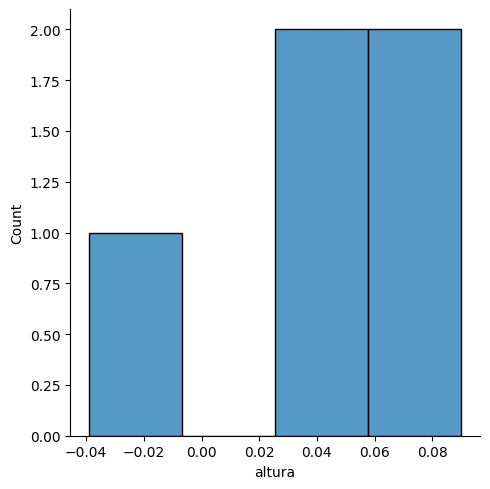

In [12]:
sns.displot  (y_test-predictions)

In [14]:
from sklearn import metrics
import numpy as np

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, predictions))

MAE: 0.05318486080700664
MSE: 0.0033126493607306537
RMSE: 0.057555619714591326
MAPE: 0.029943007687355166
